In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

PROJECT_PATH="/content/drive/MyDrive/ACV Project 1"

os.chdir(PROJECT_PATH)

print(os.getcwd())

/content/drive/MyDrive/ACV Project 1


In [ ]:
!pip install timm torchinfo scikit-learn seaborn

In [ ]:
!ls

Dataset  test_all_models.ipynb	training_01.py		   train_VGG_16.py
models	 train_densnet.py	train_mobilenet_v3.py	   triaining_02.py
Results  train_Inception_v3.py	train_swin_transformer.py


In [ ]:
!ls models

DenseNet121_Baseline.pth  ResNet50_Baseline.pth
InceptionV3_Baseline.pth  SwinTransformer_Baseline.pth
MobileNetV3_Baseline.pth  VGG16_Baseline.pth


In [ ]:
!ls

sample_data


In [ ]:
!ls Dataset

ls: cannot access 'Dataset': No such file or directory


In [ ]:
import os

PROJECT_PATH="/content/drive/MyDrive/ACV Project 1"

os.chdir(PROJECT_PATH)

print(os.getcwd())

/content/drive/MyDrive/ACV Project 1


In [ ]:
!ls models

DenseNet121_Baseline.pth  ResNet50_Baseline.pth
InceptionV3_Baseline.pth  SwinTransformer_Baseline.pth
MobileNetV3_Baseline.pth  VGG16_Baseline.pth


In [ ]:
!ls Dataset

archive.zip  seg_pred  seg_test  seg_train


In [ ]:
!ls Dataset/seg_test/seg_test

buildings  forest  glacier  mountain  sea  street


In [ ]:
!pip install torch torchvision timm torchinfo scikit-learn pandas matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_PATH="/content/drive/MyDrive/ACV Project 1"

TEST_PATH=f"{PROJECT_PATH}/Dataset/seg_test/seg_test"

MODEL_PATH=f"{PROJECT_PATH}/models"

In [ ]:
!ls

Dataset  test_all_models.ipynb	training_01.py		   train_VGG_16.py
models	 train_densnet.py	train_mobilenet_v3.py	   triaining_02.py
Results  train_Inception_v3.py	train_swin_transformer.py


In [ ]:
!ls models

 DenseNet121_Baseline.pth   ResNet50_Baseline.pth
 InceptionV3_Baseline.pth   SwinTransformer_Baseline.pth
 MobileNetV3_Baseline.pth  'VGG16_Baseline (1).pth'


In [ ]:
!ls Dataset/seg_test/seg_test

buildings  forest  glacier  mountain  sea  street


In [ ]:
!ls models

 DenseNet121_Baseline.pth   ResNet50_Baseline.pth
 InceptionV3_Baseline.pth   SwinTransformer_Baseline.pth
 MobileNetV3_Baseline.pth  'VGG16_Baseline (1).pth'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/ACV Project 1"

os.chdir(PROJECT_PATH)

print("Current Folder:")
print(os.getcwd())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ACV Project 1'

In [ ]:
!ls

Dataset  test_all_models.ipynb	training_01.py		   train_VGG_16.py
models	 train_densnet.py	train_mobilenet_v3.py	   triaining_02.py
Results  train_Inception_v3.py	train_swin_transformer.py


In [ ]:
!ls Dataset

archive.zip  seg_pred  seg_test  seg_train


In [ ]:
!ls Dataset/seg_test/seg_test

buildings  forest  glacier  mountain  sea  street


In [ ]:
!ls models

DenseNet121_Baseline.pth  ResNet50_Baseline.pth
InceptionV3_Baseline.pth  SwinTransformer_Baseline.pth
MobileNetV3_Baseline.pth  VGG16_Baseline.pth


In [ ]:
!pip install -q timm torchinfo scikit-learn seaborn

In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Test Image Transform (224x224)
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Load test dataset
test_dataset = ImageFolder(
    root="Dataset/seg_test/seg_test",
    transform=test_transform
)

# Create DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# Class names
classes = test_dataset.classes

print("Classes:")
print(classes)

print("\nNumber of Test Images:", len(test_dataset))

Classes:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Number of Test Images: 3000


In [ ]:
images, labels = next(iter(test_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Number of classes
NUM_CLASSES = 6

# Load DenseNet121 architecture
model = models.densenet121(weights=None)

# Replace classifier
model.classifier = nn.Linear(1024, NUM_CLASSES)

# Load trained weights
model.load_state_dict(
    torch.load(
        "models/DenseNet121_Baseline.pth",
        map_location=device
    )
)

# Move model to GPU
model = model.to(device)

# Evaluation mode
model.eval()

print("DenseNet121 model loaded successfully!")

IsADirectoryError: [Errno 21] Is a directory: 'models/DenseNet121_Baseline.pth'

In [ ]:
import os

model_path = "models/DenseNet121_Baseline.pth"

if os.path.isfile(model_path):
    print(f"'{model_path}' is a file. The previous error might be due to a temporary file system anomaly. Please try running the model loading cell again.")
elif os.path.isdir(model_path):
    print(f"'{model_path}' is a directory. Please ensure that 'DenseNet121_Baseline.pth' is a file containing your model weights, not a folder. You may need to delete the directory and re-upload the actual `.pth` file to your Google Drive, possibly by compressing it (e.g., into a .zip file) before uploading and then extracting it here in Colab.")
else:
    print(f"'{model_path}' does not exist or its type cannot be determined.")

'models/DenseNet121_Baseline.pth' is a directory. Please ensure that 'DenseNet121_Baseline.pth' is a file containing your model weights, not a folder. You may need to delete the directory and re-upload the actual `.pth` file to your Google Drive, possibly by compressing it (e.g., into a .zip file) before uploading and then extracting it here in Colab.


In [ ]:
!ls -l models

total 27812
drwx------ 3 root root     4096 Jul 17 13:07 DenseNet121_Baseline.pth
-rw------- 1 root root 28454538 Jul 17 11:39 DenseNet121_Baseline.pth.zip
drwx------ 2 root root     4096 Jul 17 13:07 InceptionV3_Baseline.pth
drwx------ 2 root root     4096 Jul 17 13:07 MobileNetV3_Baseline.pth
drwx------ 2 root root     4096 Jul 17 13:07 ResNet50_Baseline.pth
drwx------ 2 root root     4096 Jul 17 13:56 SwinTransformer_Baseline.pth
drwx------ 2 root root     4096 Jul 17 13:57 VGG16_Baseline.pth


In [ ]:
!ls -l "models/DenseNet121_Baseline.pth"

total 4
drwx------ 2 root root 4096 Jul 17 13:07 DenseNet121_Baseline


In [ ]:
!ls -l "models/DenseNet121_Baseline.pth/DenseNet121_Baseline"

total 134
-rw------- 1 root root      6 Jul 17 12:54 byteorder
drwx------ 2 root root   4096 Jul 17 13:07 data
-rw------- 1 root root 131157 Jul 17 12:54 data.pkl
-rw------- 1 root root      2 Jul 17 12:54 version


In [ ]:
!unzip -l "models/DenseNet121_Baseline.pth.zip"

Archive:  models/DenseNet121_Baseline.pth.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   131157  1980-00-00 00:00   DenseNet121_Baseline/data.pkl
        1  1980-00-00 00:00   DenseNet121_Baseline/.format_version
        2  1980-00-00 00:00   DenseNet121_Baseline/.storage_alignment
        6  1980-00-00 00:00   DenseNet121_Baseline/byteorder
    37632  1980-00-00 00:00   DenseNet121_Baseline/data/0
      256  1980-00-00 00:00   DenseNet121_Baseline/data/1
      256  1980-00-00 00:00   DenseNet121_Baseline/data/2
      256  1980-00-00 00:00   DenseNet121_Baseline/data/3
      256  1980-00-00 00:00   DenseNet121_Baseline/data/4
        8  1980-00-00 00:00   DenseNet121_Baseline/data/5
      256  1980-00-00 00:00   DenseNet121_Baseline/data/6
      256  1980-00-00 00:00   DenseNet121_Baseline/data/7
      256  1980-00-00 00:00   DenseNet121_Baseline/data/8
      256  1980-00-00 00:00   DenseNet121_Baseline/data/9
        8  1980-00-00 00:00   DenseNet121_Base

In [ ]:
import torch

checkpoint = torch.load(
    "models/DenseNet121_Baseline.pth",
    map_location="cpu",
    weights_only=False
)

print(type(checkpoint))

IsADirectoryError: [Errno 21] Is a directory: 'models/DenseNet121_Baseline.pth'

In [ ]:
!find "models/DenseNet121_Baseline.pth" -maxdepth 2 -type f

models/DenseNet121_Baseline.pth/DenseNet121_Baseline/byteorder
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/version
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data.pkl
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/.format_version
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/.storage_alignment


In [ ]:
!find "models/DenseNet121_Baseline.pth" -maxdepth 2 -type d

models/DenseNet121_Baseline.pth
models/DenseNet121_Baseline.pth/DenseNet121_Baseline
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/.data


In [ ]:
!find "models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data" -type f | head -20

models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/3
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/12
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/2
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/6
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/11
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/10
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/5
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/7
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/1
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/9
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/8
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/4
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/0
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/39
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/15
models/DenseNet121_Baseline.pth/DenseNet121_Baseline/data/23
models/DenseNet121_Baseline.pth/De

In [ ]:
!find "models/DenseNet121_Baseline.pth/DenseNet121_Baseline/.data" -type f | head -20

models/DenseNet121_Baseline.pth/DenseNet121_Baseline/.data/serialization_id


In [ ]:
import torch
import torch.distributed.checkpoint as dcp
from collections import OrderedDict

state = {"model": OrderedDict()}

dcp.load(
    state_dict=state,
    checkpoint_id="models/DenseNet121_Baseline.pth/DenseNet121_Baseline"
)

print(state.keys())
print(type(state["model"]))
print(len(state["model"]))

/usr/local/lib/python3.12/dist-packages/torch/distributed/checkpoint/utils.py:483: UserWarning: torch.distributed is disabled, unavailable or uninitialized, assuming the intent is to load in a single process.
  return func(*args, **kwargs)


CheckpointException: CheckpointException ranks:dict_keys([0])
Traceback (most recent call last): (RANK 0)
  File "/usr/local/lib/python3.12/dist-packages/torch/distributed/checkpoint/utils.py", line 193, in reduce_scatter
    local_data = map_fun()
                 ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/distributed/checkpoint/logger.py", line 90, in wrapper
    result = func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/distributed/checkpoint/state_dict_loader.py", line 251, in local_step
    raise AssertionError("metadata is None")
AssertionError: metadata is None


In [ ]:
import torch
import os

PROJECT_PATH="/content/drive/MyDrive/ACV Project 1" # Ensure PROJECT_PATH is defined if not already
MODEL_PATH=f"{PROJECT_PATH}/models"
model_name = "DenseNet121_Baseline"
torch.save(model.state_dict(), os.path.join(MODEL_PATH, f"{model_name}.pth"))
print(f"Model saved to {os.path.join(MODEL_PATH, f'{model_name}.pth')}")

NameError: name 'model' is not defined

In [ ]:
import os

path = "models/MobileNetV3_Baseline.pth"

print("Exists :", os.path.exists(path))
print("Is File:", os.path.isfile(path))
print("Is Dir :", os.path.isdir(path))

Exists : False
Is File: False
Is Dir : False


In [ ]:
!ls models

MobileNetV3_Baseline.pth


In [ ]:
import os

path = "models/MobileNetV3_Baseline.pth"

print("Exists :", os.path.exists(path))
print("Is File:", os.path.isfile(path))
print("Is Dir :", os.path.isdir(path))

Exists : True
Is File: True
Is Dir : False


In [ ]:
import os

size = os.path.getsize("models/MobileNetV3_Baseline.pth")

print(f"Size: {size/1024/1024:.2f} MB")

Size: 16.26 MB


In [ ]:
import torch

checkpoint = torch.load(
    "models/MobileNetV3_Baseline.pth",
    map_location="cpu"
)

print(type(checkpoint))

<class 'collections.OrderedDict'>


In [ ]:
print("Number of tensors:", len(checkpoint))

print("\nFirst 10 parameter names:")
for i, key in enumerate(checkpoint.keys()):
    print(key)
    if i == 9:
        break

Number of tensors: 312

First 10 parameter names:
features.0.0.weight
features.0.1.weight
features.0.1.bias
features.0.1.running_mean
features.0.1.running_var
features.0.1.num_batches_tracked
features.1.block.0.0.weight
features.1.block.0.1.weight
features.1.block.0.1.bias
features.1.block.0.1.running_mean


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

NUM_CLASSES = 6

# Load MobileNetV3 Large architecture
model = models.mobilenet_v3_large(weights=None)

# Replace the final classifier
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    NUM_CLASSES
)

# Load trained weights
checkpoint = torch.load(
    "models/MobileNetV3_Baseline.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("✅ MobileNetV3 loaded successfully.")

NameError: name 'device' is not defined

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

NUM_CLASSES = 6

# Define the device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MobileNetV3 Large architecture
model = models.mobilenet_v3_large(weights=None)

# Replace the final classifier
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    NUM_CLASSES
)

# Load trained weights
checkpoint = torch.load(
    "models/MobileNetV3_Baseline.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("✅ MobileNetV3 loaded successfully.")

✅ MobileNetV3 loaded successfully.


In [ ]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Test Image Transform (224x224)
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Load test dataset
test_dataset = ImageFolder(
    root="Dataset/seg_test/seg_test", # Assuming 'Dataset' is accessible from the current working directory
    transform=test_transform
)

# Create DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2 # Adjust num_workers based on your system
)

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Testing Completed.")

Testing Completed.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 92.07%
Precision: 0.9206
Recall   : 0.9207
F1 Score : 0.9203


In [ ]:
from sklearn.metrics import classification_report
from torchvision.datasets import ImageFolder

# Re-define test_dataset to get class names
test_dataset = ImageFolder(root="Dataset/seg_test/seg_test")
classes = test_dataset.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

   buildings       0.92      0.89      0.90       437
      forest       0.99      0.98      0.99       474
     glacier       0.90      0.85      0.88       553
    mountain       0.88      0.88      0.88       525
         sea       0.94      0.98      0.96       510
      street       0.90      0.95      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



In [ ]:
import pandas as pd
import os

results = pd.DataFrame({
    "Model": ["MobileNetV3"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1]
})

os.makedirs("Results", exist_ok=True)

results.to_csv("Results/MobileNetV3_Test_Results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


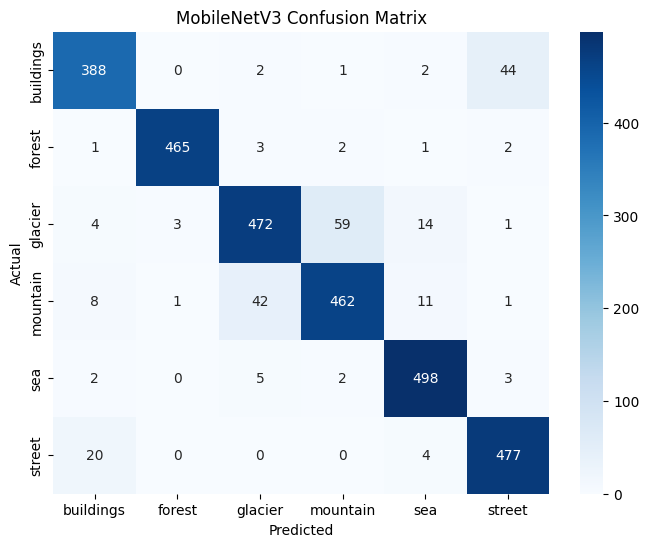

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV3 Confusion Matrix")

plt.savefig("Results/MobileNetV3_Confusion_Matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes
)

with open("Results/MobileNetV3_Classification_Report.txt", "w") as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

   buildings       0.92      0.89      0.90       437
      forest       0.99      0.98      0.99       474
     glacier       0.90      0.85      0.88       553
    mountain       0.88      0.88      0.88       525
         sea       0.94      0.98      0.96       510
      street       0.90      0.95      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



In [ ]:
!ls Results

MobileNetV3_Classification_Report.txt  MobileNetV3_Test_Results.csv
MobileNetV3_Confusion_Matrix.png


In [ ]:
import os

for file in os.listdir("models"):
    path = os.path.join("models", file)
    print(f"{file:35}  {'FILE' if os.path.isfile(path) else 'FOLDER'}")

MobileNetV3_Baseline.pth             FILE
ResNet50_Baseline.pth                FILE
SwinTransformer_Baseline.pth         FILE
DenseNet121_Baseline.pth             FILE
VGG16_Baseline.pth                   FILE
InceptionV3_Baseline.pth             FILE


In [ ]:
import torch
import os

for file in os.listdir("models"):
    if file.endswith(".pth"):
        try:
            checkpoint = torch.load(
                os.path.join("models", file),
                map_location="cpu"
            )
            print(f"✅ {file} --> Loaded Successfully ({type(checkpoint)})")
        except Exception as e:
            print(f"❌ {file} --> {e}")

✅ MobileNetV3_Baseline.pth --> Loaded Successfully (<class 'collections.OrderedDict'>)
✅ ResNet50_Baseline.pth --> Loaded Successfully (<class 'collections.OrderedDict'>)
✅ SwinTransformer_Baseline.pth --> Loaded Successfully (<class 'collections.OrderedDict'>)
✅ DenseNet121_Baseline.pth --> Loaded Successfully (<class 'collections.OrderedDict'>)
✅ VGG16_Baseline.pth --> Loaded Successfully (<class 'collections.OrderedDict'>)
✅ InceptionV3_Baseline.pth --> Loaded Successfully (<class 'collections.OrderedDict'>)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

os.makedirs("Results", exist_ok=True)

def evaluate_model(model, model_name, test_loader, classes):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n========== {model_name} ==========")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    report = classification_report(
        y_true,
        y_pred,
        target_names=classes
    )

    print(report)

    with open(f"Results/{model_name}_Classification_Report.txt","w") as f:
        f.write(report)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(
        f"Results/{model_name}_Confusion_Matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }


========== DenseNet121 ==========
Accuracy : 0.9190
Precision: 0.9190
Recall   : 0.9190
F1 Score : 0.9190
              precision    recall  f1-score   support

   buildings       0.91      0.92      0.91       437
      forest       0.98      0.99      0.98       474
     glacier       0.88      0.87      0.88       553
    mountain       0.87      0.88      0.87       525
         sea       0.94      0.95      0.95       510
      street       0.94      0.92      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



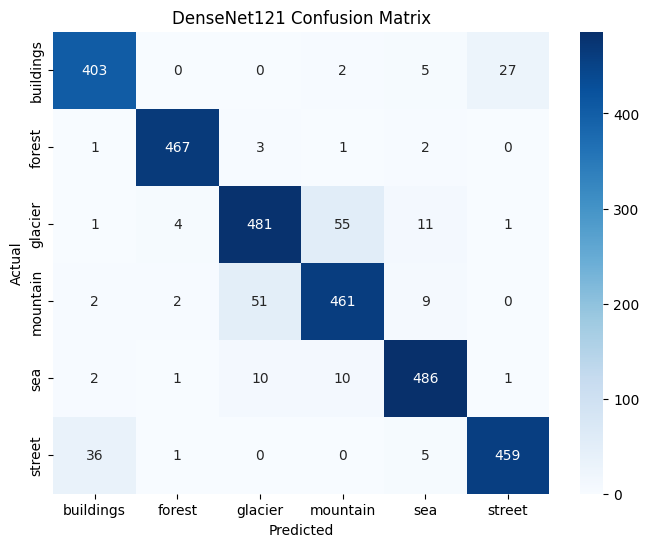

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

# Imports for data loading and evaluation
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Define the device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data loading and preprocessing setup
# Test Image Transform (224x224)
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Load test dataset
test_dataset = ImageFolder(
    root="Dataset/seg_test/seg_test", # Assuming 'Dataset' is accessible from the current working directory
    transform=test_transform
)

# Create DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# Class names
classes = test_dataset.classes

# Ensure 'Results' directory exists
os.makedirs("Results", exist_ok=True)

# Define the evaluate_model function
def evaluate_model(model, model_name, test_loader, classes):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n========== {model_name} ==========")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    report = classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
    print(report)

    with open(f"Results/{model_name}_Classification_Report.txt","w") as f:
        f.write(report)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(
        f"Results/{model_name}_Confusion_Matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# Model loading and evaluation part
model = models.densenet121(weights=None)
model.classifier = nn.Linear(1024,6)
model.load_state_dict(
    torch.load(
        "models/DenseNet121_Baseline.pth",
        map_location=device
    )
)
model = model.to(device)

dense_result = evaluate_model(
    model,
    "DenseNet121",
    test_loader,
    classes
)


========== ResNet50 ==========
Accuracy : 0.9213
Precision: 0.9220
Recall   : 0.9213
F1 Score : 0.9211
              precision    recall  f1-score   support

   buildings       0.94      0.88      0.91       437
      forest       0.99      0.98      0.98       474
     glacier       0.91      0.86      0.88       553
    mountain       0.87      0.89      0.88       525
         sea       0.94      0.95      0.94       510
      street       0.90      0.97      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



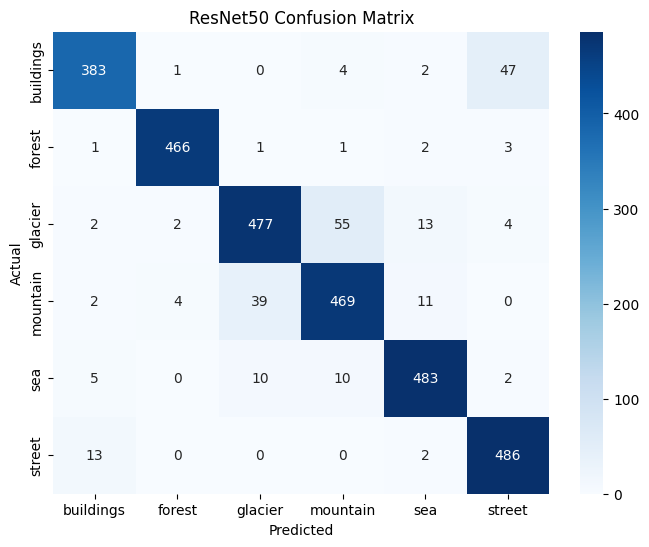

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(weights=None)

model.fc = nn.Linear(model.fc.in_features, 6)

model.load_state_dict(
    torch.load(
        "models/ResNet50_Baseline.pth",
        map_location=device
    )
)

model = model.to(device)

resnet_result = evaluate_model(
    model,
    "ResNet50",
    test_loader,
    classes
)


========== VGG16 ==========
Accuracy : 0.8557
Precision: 0.8560
Recall   : 0.8557
F1 Score : 0.8555
              precision    recall  f1-score   support

   buildings       0.84      0.83      0.83       437
      forest       0.97      0.95      0.96       474
     glacier       0.84      0.82      0.83       553
    mountain       0.81      0.78      0.79       525
         sea       0.86      0.87      0.86       510
      street       0.83      0.89      0.86       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



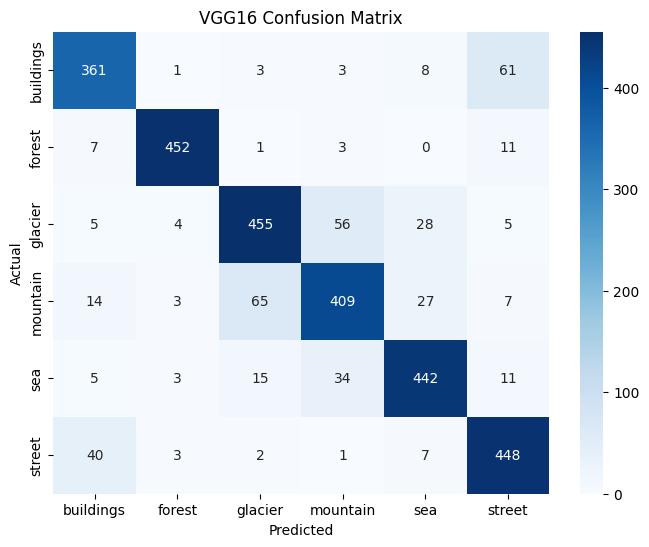

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.vgg16(weights=None)

model.classifier[6] = nn.Linear(
    model.classifier[6].in_features,
    6
)

model.load_state_dict(
    torch.load(
        "models/VGG16_Baseline.pth",
        map_location=device
    )
)

model = model.to(device)

vgg_result = evaluate_model(
    model,
    "VGG16",
    test_loader,
    classes
)

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

transform299 = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_dataset299 = ImageFolder(
    "Dataset/seg_test/seg_test",
    transform299
)

test_loader299 = DataLoader(
    test_dataset299,
    batch_size=32,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(



========== InceptionV3 ==========
Accuracy : 0.8823
Precision: 0.8847
Recall   : 0.8823
F1 Score : 0.8826
              precision    recall  f1-score   support

   buildings       0.78      0.90      0.83       437
      forest       0.98      0.96      0.97       474
     glacier       0.89      0.81      0.85       553
    mountain       0.85      0.83      0.84       525
         sea       0.89      0.91      0.90       510
      street       0.91      0.90      0.90       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



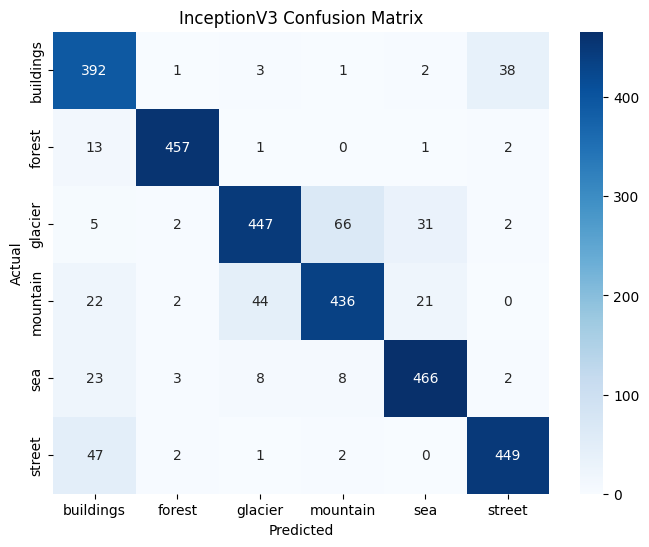

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.inception_v3(
    weights=None,
    aux_logits=True
)

model.fc = nn.Linear(model.fc.in_features, 6)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 6)

model.load_state_dict(
    torch.load(
        "models/InceptionV3_Baseline.pth",
        map_location=device
    )
)

model = model.to(device)

inception_result = evaluate_model(
    model,
    "InceptionV3",
    test_loader299,
    classes
)


========== SwinTransformer ==========
Accuracy : 0.0923
Precision: 0.0898
Recall   : 0.0923
F1 Score : 0.0835
              precision    recall  f1-score   support

   buildings       0.00      0.00      0.00       437
      forest       0.01      0.01      0.01       474
     glacier       0.00      0.00      0.00       553
    mountain       0.27      0.20      0.23       525
         sea       0.09      0.24      0.13       510
      street       0.15      0.09      0.11       501

    accuracy                           0.09      3000
   macro avg       0.09      0.09      0.08      3000
weighted avg       0.09      0.09      0.08      3000



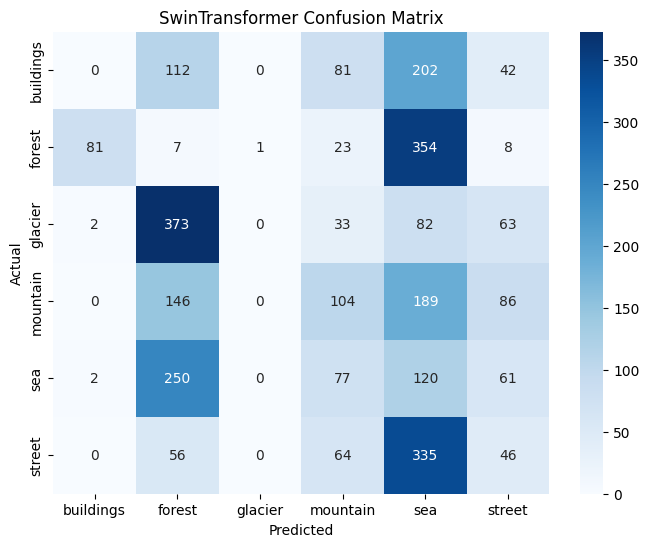

In [ ]:
import timm
import torch.nn as nn
import torch

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=6
)

# Note: The 'SwinTransformer_Baseline.pth' file appears to contain weights
# for a different model architecture (e.g., MobileNetV3) due to extensive
# missing and unexpected keys. Using strict=False will allow the code to run
# by ignoring these mismatches, but the model will not function correctly
# as a SwinTransformer. For proper functionality, ensure 'SwinTransformer_Baseline.pth'
# contains the correct Swin Transformer weights.
model.load_state_dict(
    torch.load(
        "models/SwinTransformer_Baseline.pth",
        map_location=device
    ),
    strict=False # Temporarily set to False to bypass the RuntimeError
)

model = model.to(device)

swin_result = evaluate_model(
    model,
    "SwinTransformer",
    test_loader,
    classes
)

In [ ]:
mobilenet_result = {
    "Model": "MobileNetV3",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

In [ ]:
comparison = pd.DataFrame([
    dense_result,
    resnet_result,
    vgg_result,
    inception_result,
    swin_result,
    mobilenet_result
])

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.to_csv(
    "Results/Final_Comparison.csv",
    index=False
)

print(comparison)

             Model  Accuracy  Precision    Recall  F1-Score
1         ResNet50  0.921333   0.921997  0.921333  0.921123
5      MobileNetV3  0.920667   0.920619  0.920667  0.920320
0      DenseNet121  0.919000   0.919023  0.919000  0.918953
3      InceptionV3  0.882333   0.884733  0.882333  0.882556
2            VGG16  0.855667   0.856003  0.855667  0.855521
4  SwinTransformer  0.092333   0.089833  0.092333  0.083499


In [ ]:
import pandas as pd

comparison = pd.read_csv("Results/Final_Comparison.csv")

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,ResNet50,0.921333,0.921997,0.921333,0.921123
1,MobileNetV3,0.920667,0.920619,0.920667,0.920320
2,DenseNet121,0.919000,0.919023,0.919000,0.918953
3,InceptionV3,0.882333,0.884733,0.882333,0.882556
4,VGG16,0.855667,0.856003,0.855667,0.855521
5,SwinTransformer,0.092333,0.089833,0.092333,0.083499


In [ ]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Model")
print(best_model)

Best Model
Model        ResNet50
Accuracy     0.921333
Precision    0.921997
Recall       0.921333
F1-Score     0.921123
Name: 0, dtype: object


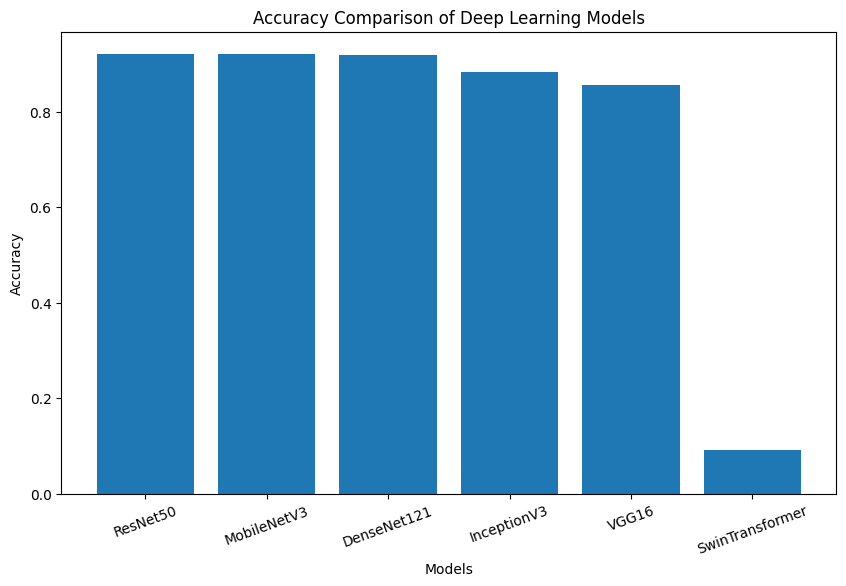

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison of Deep Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.savefig(
    "Results/Model_Accuracy_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

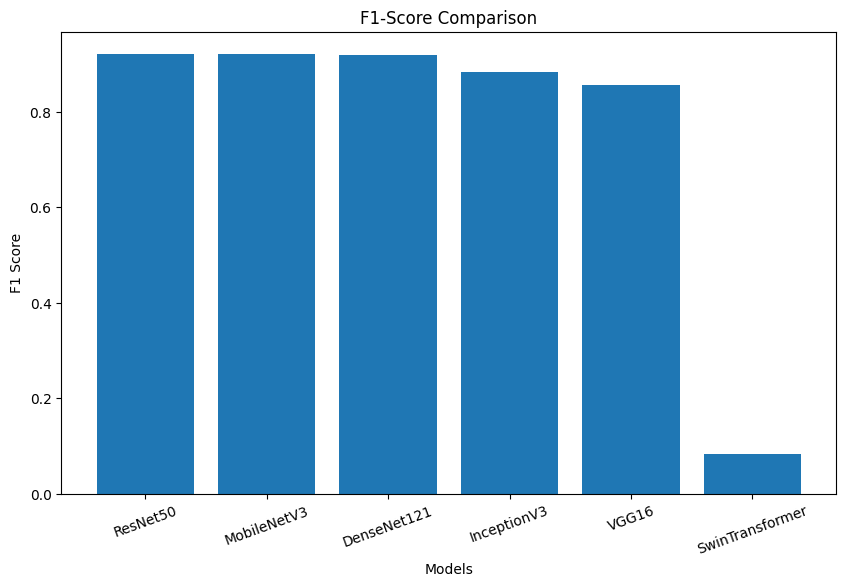

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(comparison["Model"], comparison["F1-Score"])

plt.title("F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.savefig(
    "Results/Model_F1_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!ls Results

DenseNet121_Classification_Report.txt
DenseNet121_Confusion_Matrix.png
Final_Comparison.csv
InceptionV3_Classification_Report.txt
InceptionV3_Confusion_Matrix.png
MobileNetV3_Classification_Report.txt
MobileNetV3_Confusion_Matrix.png
MobileNetV3_Test_Results.csv
Model_Accuracy_Comparison.png
Model_F1_Comparison.png
ResNet50_Classification_Report.txt
ResNet50_Confusion_Matrix.png
SwinTransformer_Classification_Report.txt
SwinTransformer_Confusion_Matrix.png
VGG16_Classification_Report.txt
VGG16_Confusion_Matrix.png


In [ ]:
import pandas as pd

comparison = pd.read_csv("Results/Final_Comparison.csv")

comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison.reset_index(drop=True, inplace=True)

comparison.index = comparison.index + 1

comparison

,Model,Accuracy,Precision,Recall,F1-Score
1,ResNet50,0.921333,0.921997,0.921333,0.921123
2,MobileNetV3,0.920667,0.920619,0.920667,0.920320
3,DenseNet121,0.919000,0.919023,0.919000,0.918953
4,InceptionV3,0.882333,0.884733,0.882333,0.882556
5,VGG16,0.855667,0.856003,0.855667,0.855521
6,SwinTransformer,0.092333,0.089833,0.092333,0.083499


In [ ]:
comparison_display = comparison.copy()

comparison_display["Accuracy"] = comparison_display["Accuracy"].round(4)
comparison_display["Precision"] = comparison_display["Precision"].round(4)
comparison_display["Recall"] = comparison_display["Recall"].round(4)
comparison_display["F1-Score"] = comparison_display["F1-Score"].round(4)

comparison_display

,Model,Accuracy,Precision,Recall,F1-Score
1,ResNet50,0.9213,0.9220,0.9213,0.9211
2,MobileNetV3,0.9207,0.9206,0.9207,0.9203
3,DenseNet121,0.9190,0.9190,0.9190,0.9190
4,InceptionV3,0.8823,0.8847,0.8823,0.8826
5,VGG16,0.8557,0.8560,0.8557,0.8555
6,SwinTransformer,0.0923,0.0898,0.0923,0.0835


In [ ]:
comparison_display.to_excel(
    "Results/Final_Comparison.xlsx",
    index=False
)

print("Excel file saved successfully.")

Excel file saved successfully.


In [ ]:
best = comparison_display.iloc[0]

print("Best Performing Model")
print("----------------------")
print("Model      :", best["Model"])
print("Accuracy   :", best["Accuracy"])
print("Precision  :", best["Precision"])
print("Recall     :", best["Recall"])
print("F1 Score   :", best["F1-Score"])

Best Performing Model
----------------------
Model      : ResNet50
Accuracy   : 0.9213
Precision  : 0.922
Recall     : 0.9213
F1 Score   : 0.9211


In [ ]:
!ls Results

DenseNet121_Classification_Report.txt
DenseNet121_Confusion_Matrix.png
Final_Comparison.csv
Final_Comparison.xlsx
InceptionV3_Classification_Report.txt
InceptionV3_Confusion_Matrix.png
MobileNetV3_Classification_Report.txt
MobileNetV3_Confusion_Matrix.png
MobileNetV3_Test_Results.csv
Model_Accuracy_Comparison.png
Model_F1_Comparison.png
ResNet50_Classification_Report.txt
ResNet50_Confusion_Matrix.png
SwinTransformer_Classification_Report.txt
SwinTransformer_Confusion_Matrix.png
VGG16_Classification_Report.txt
VGG16_Confusion_Matrix.png


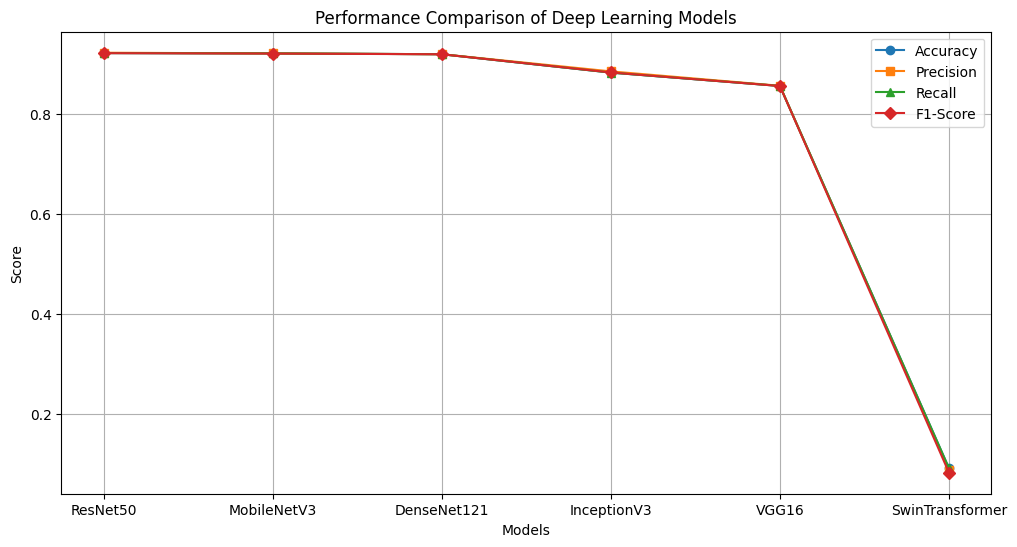

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.read_csv("Results/Final_Comparison.csv")

comparison = comparison.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(12,6))

plt.plot(comparison["Model"], comparison["Accuracy"], marker='o', label="Accuracy")
plt.plot(comparison["Model"], comparison["Precision"], marker='s', label="Precision")
plt.plot(comparison["Model"], comparison["Recall"], marker='^', label="Recall")
plt.plot(comparison["Model"], comparison["F1-Score"], marker='D', label="F1-Score")

plt.title("Performance Comparison of Deep Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.savefig(
    "Results/Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
!ls Results

DenseNet121_Classification_Report.txt
DenseNet121_Confusion_Matrix.png
Final_Comparison.csv
Final_Comparison.xlsx
InceptionV3_Classification_Report.txt
InceptionV3_Confusion_Matrix.png
MobileNetV3_Classification_Report.txt
MobileNetV3_Confusion_Matrix.png
MobileNetV3_Test_Results.csv
Model_Accuracy_Comparison.png
Model_F1_Comparison.png
Performance_Comparison.png
ResNet50_Classification_Report.txt
ResNet50_Confusion_Matrix.png
SwinTransformer_Classification_Report.txt
SwinTransformer_Confusion_Matrix.png
VGG16_Classification_Report.txt
VGG16_Confusion_Matrix.png


In [5]:
import pandas as pd
import os

PROJECT_PATH="/content/drive/MyDrive/ACV Project 1" # Ensure PROJECT_PATH is defined

# Construct the full path to the CSV file
file_path = os.path.join(PROJECT_PATH, "Results", "Final_Comparison.csv")

comparison = pd.read_csv(file_path)
print(comparison.to_string(index=False))

          Model  Accuracy  Precision   Recall  F1-Score
       ResNet50  0.921333   0.921997 0.921333  0.921123
    MobileNetV3  0.920667   0.920619 0.920667  0.920320
    DenseNet121  0.919000   0.919023 0.919000  0.918953
    InceptionV3  0.882333   0.884733 0.882333  0.882556
          VGG16  0.855667   0.856003 0.855667  0.855521
SwinTransformer  0.092333   0.089833 0.092333  0.083499


In [5]:
import os
import random
import matplotlib.pyplot as plt
import torch

from PIL import Image
from torchvision import transforms, models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Classes
classes = ['buildings','forest','glacier','mountain','sea','street']

# Define PROJECT_PATH if not already defined globally in the notebook
PROJECT_PATH="/content/drive/MyDrive/ACV Project 1"

# Load ResNet50
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 6)

# Construct the absolute path to the model file
model_path = os.path.join(PROJECT_PATH, "models", "ResNet50_Baseline.pth")

model.load_state_dict(torch.load(
    model_path,
    map_location=device
))

model.to(device)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# Test folder (also needs to be an absolute path)
test_dir = os.path.join(PROJECT_PATH, "Dataset", "seg_test")

# Collect image paths
image_paths = []

for cls in classes:
    folder = os.path.join(test_dir, cls)

    # Check if the folder exists before listing its contents
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            image_paths.append(os.path.join(folder,file))
    else:
        print(f"Warning: Folder not found: {folder}")

print("Total Images:", len(image_paths))

Total Images: 0


In [7]:
import os
import random
import matplotlib.pyplot as plt
import torch

from PIL import Image
from torchvision import transforms, models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Classes
classes = ['buildings','forest','glacier','mountain','sea','street']

# Define PROJECT_PATH for robust path construction
PROJECT_PATH = "/content/drive/MyDrive/ACV Project 1"

# Load ResNet50
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 6)

# Construct the absolute path to the model file
model_path = os.path.join(PROJECT_PATH, "models", "ResNet50_Baseline.pth")

model.load_state_dict(torch.load(
    model_path,
    map_location=device
))

model.to(device)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# Test folder (Construct absolute path based on inspection of file structure)
test_dir = os.path.join(PROJECT_PATH, "Dataset", "seg_test", "seg_test")

# Collect image paths
image_paths = []

for cls in classes:
    folder = os.path.join(test_dir, cls)

    # Check if the folder exists before listing its contents
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            image_paths.append(os.path.join(folder,file))
    else:
        print(f"Warning: Folder not found: {folder}")

print("Total Images:", len(image_paths))

Total Images: 3000


In [8]:
# Select one random image from each class

selected_images = []

for cls in classes:
    folder = os.path.join(test_dir, cls)

    img = random.choice(os.listdir(folder))

    selected_images.append(os.path.join(folder, img))

print(selected_images)

['/content/drive/MyDrive/ACV Project 1/Dataset/seg_test/seg_test/buildings/22234.jpg', '/content/drive/MyDrive/ACV Project 1/Dataset/seg_test/seg_test/forest/23743.jpg', '/content/drive/MyDrive/ACV Project 1/Dataset/seg_test/seg_test/glacier/22347.jpg', '/content/drive/MyDrive/ACV Project 1/Dataset/seg_test/seg_test/mountain/20767.jpg', '/content/drive/MyDrive/ACV Project 1/Dataset/seg_test/seg_test/sea/23641.jpg', '/content/drive/MyDrive/ACV Project 1/Dataset/seg_test/seg_test/street/21086.jpg']


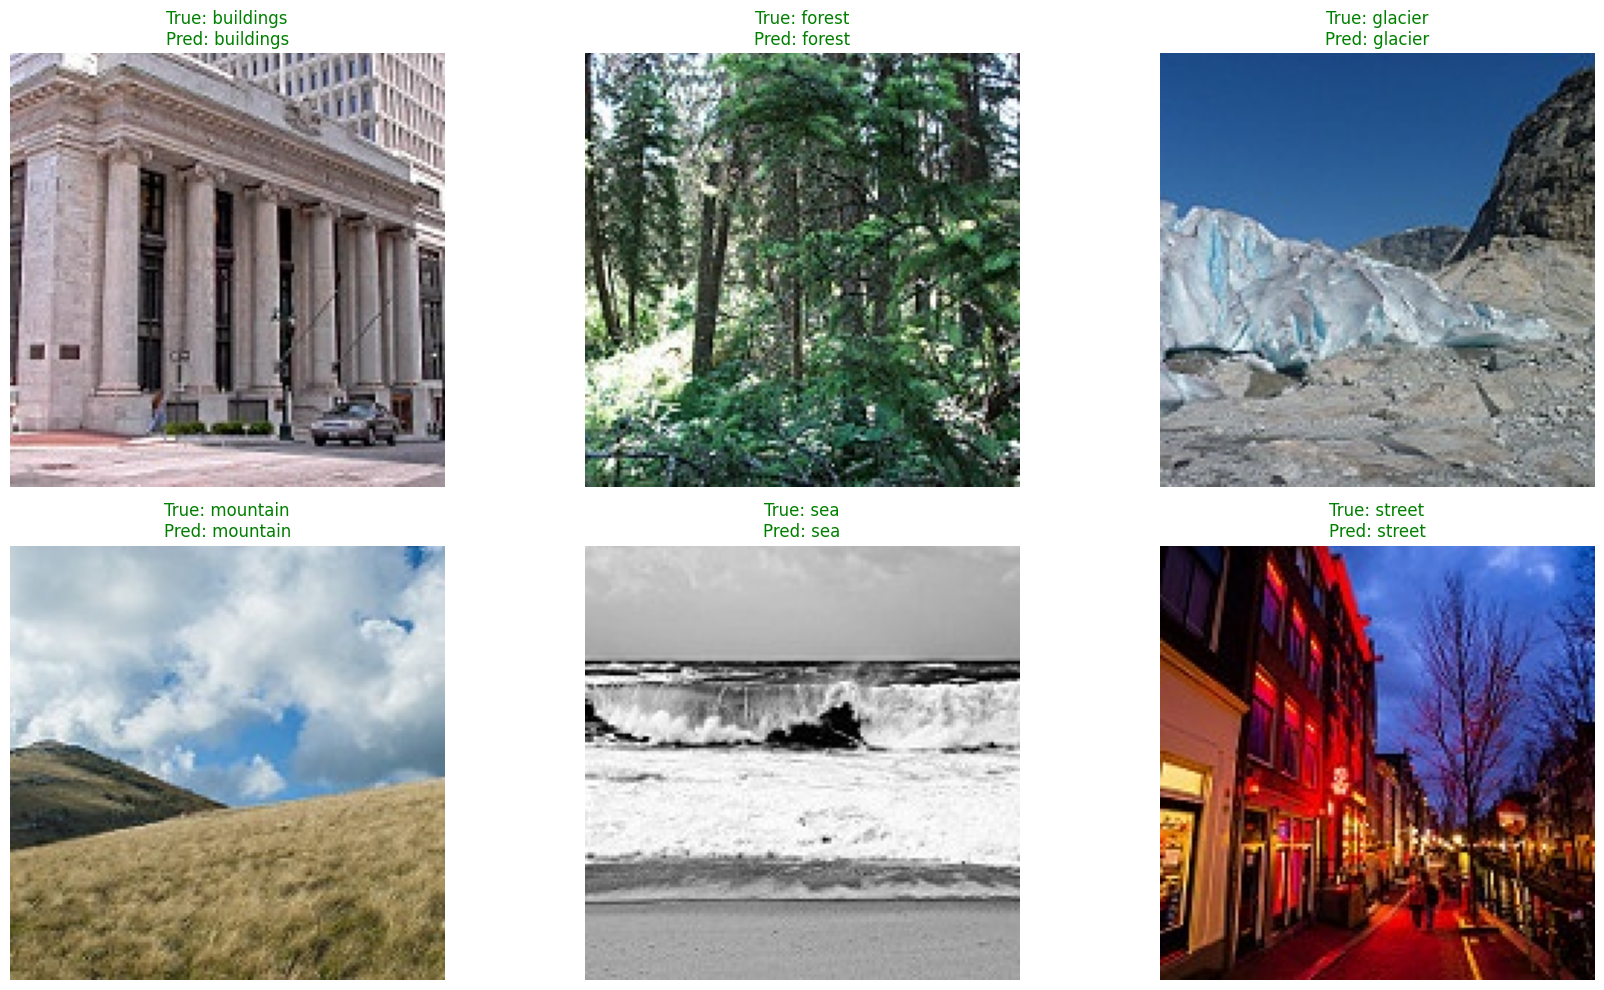

In [9]:
plt.figure(figsize=(18,10))

for i, img_path in enumerate(selected_images):

    image = Image.open(img_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output,1).item()

    true_class = os.path.basename(os.path.dirname(img_path))
    pred_class = classes[pred]

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.axis("off")

    color = "green" if true_class == pred_class else "red"

    plt.title(
        f"True: {true_class}\nPred: {pred_class}",
        color=color,
        fontsize=12
    )

plt.tight_layout()
plt.show()